Обучение HyperImpute (missforest) на 7 признаках >>> 
Запуск Optuna (5 итераций) >>>

[Optuna] Лучшие найденные параметры:
  n_estimators: 200
  max_depth: 36
  min_samples_split: 11
  min_samples_leaf: 5
  max_features: log2
  class_weight: None
[Optuna] Лучший Validation F1 Weighted: 0.8540

Обучение финальной модели RandomForest >>>

Отчет по классификации (Validation):
               precision    recall  f1-score   support

 Argillaceous       0.86      0.96      0.91    188834
   Carbonates       0.86      0.61      0.71     15501
         Coal       0.85      0.43      0.57       514
   Evaporites       0.99      0.89      0.93      4139
Siliciclastic       0.84      0.65      0.73     67254

     accuracy                           0.86    276242
    macro avg       0.88      0.71      0.77    276242
 weighted avg       0.86      0.86      0.85    276242

Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/hyperimpute_rf_test

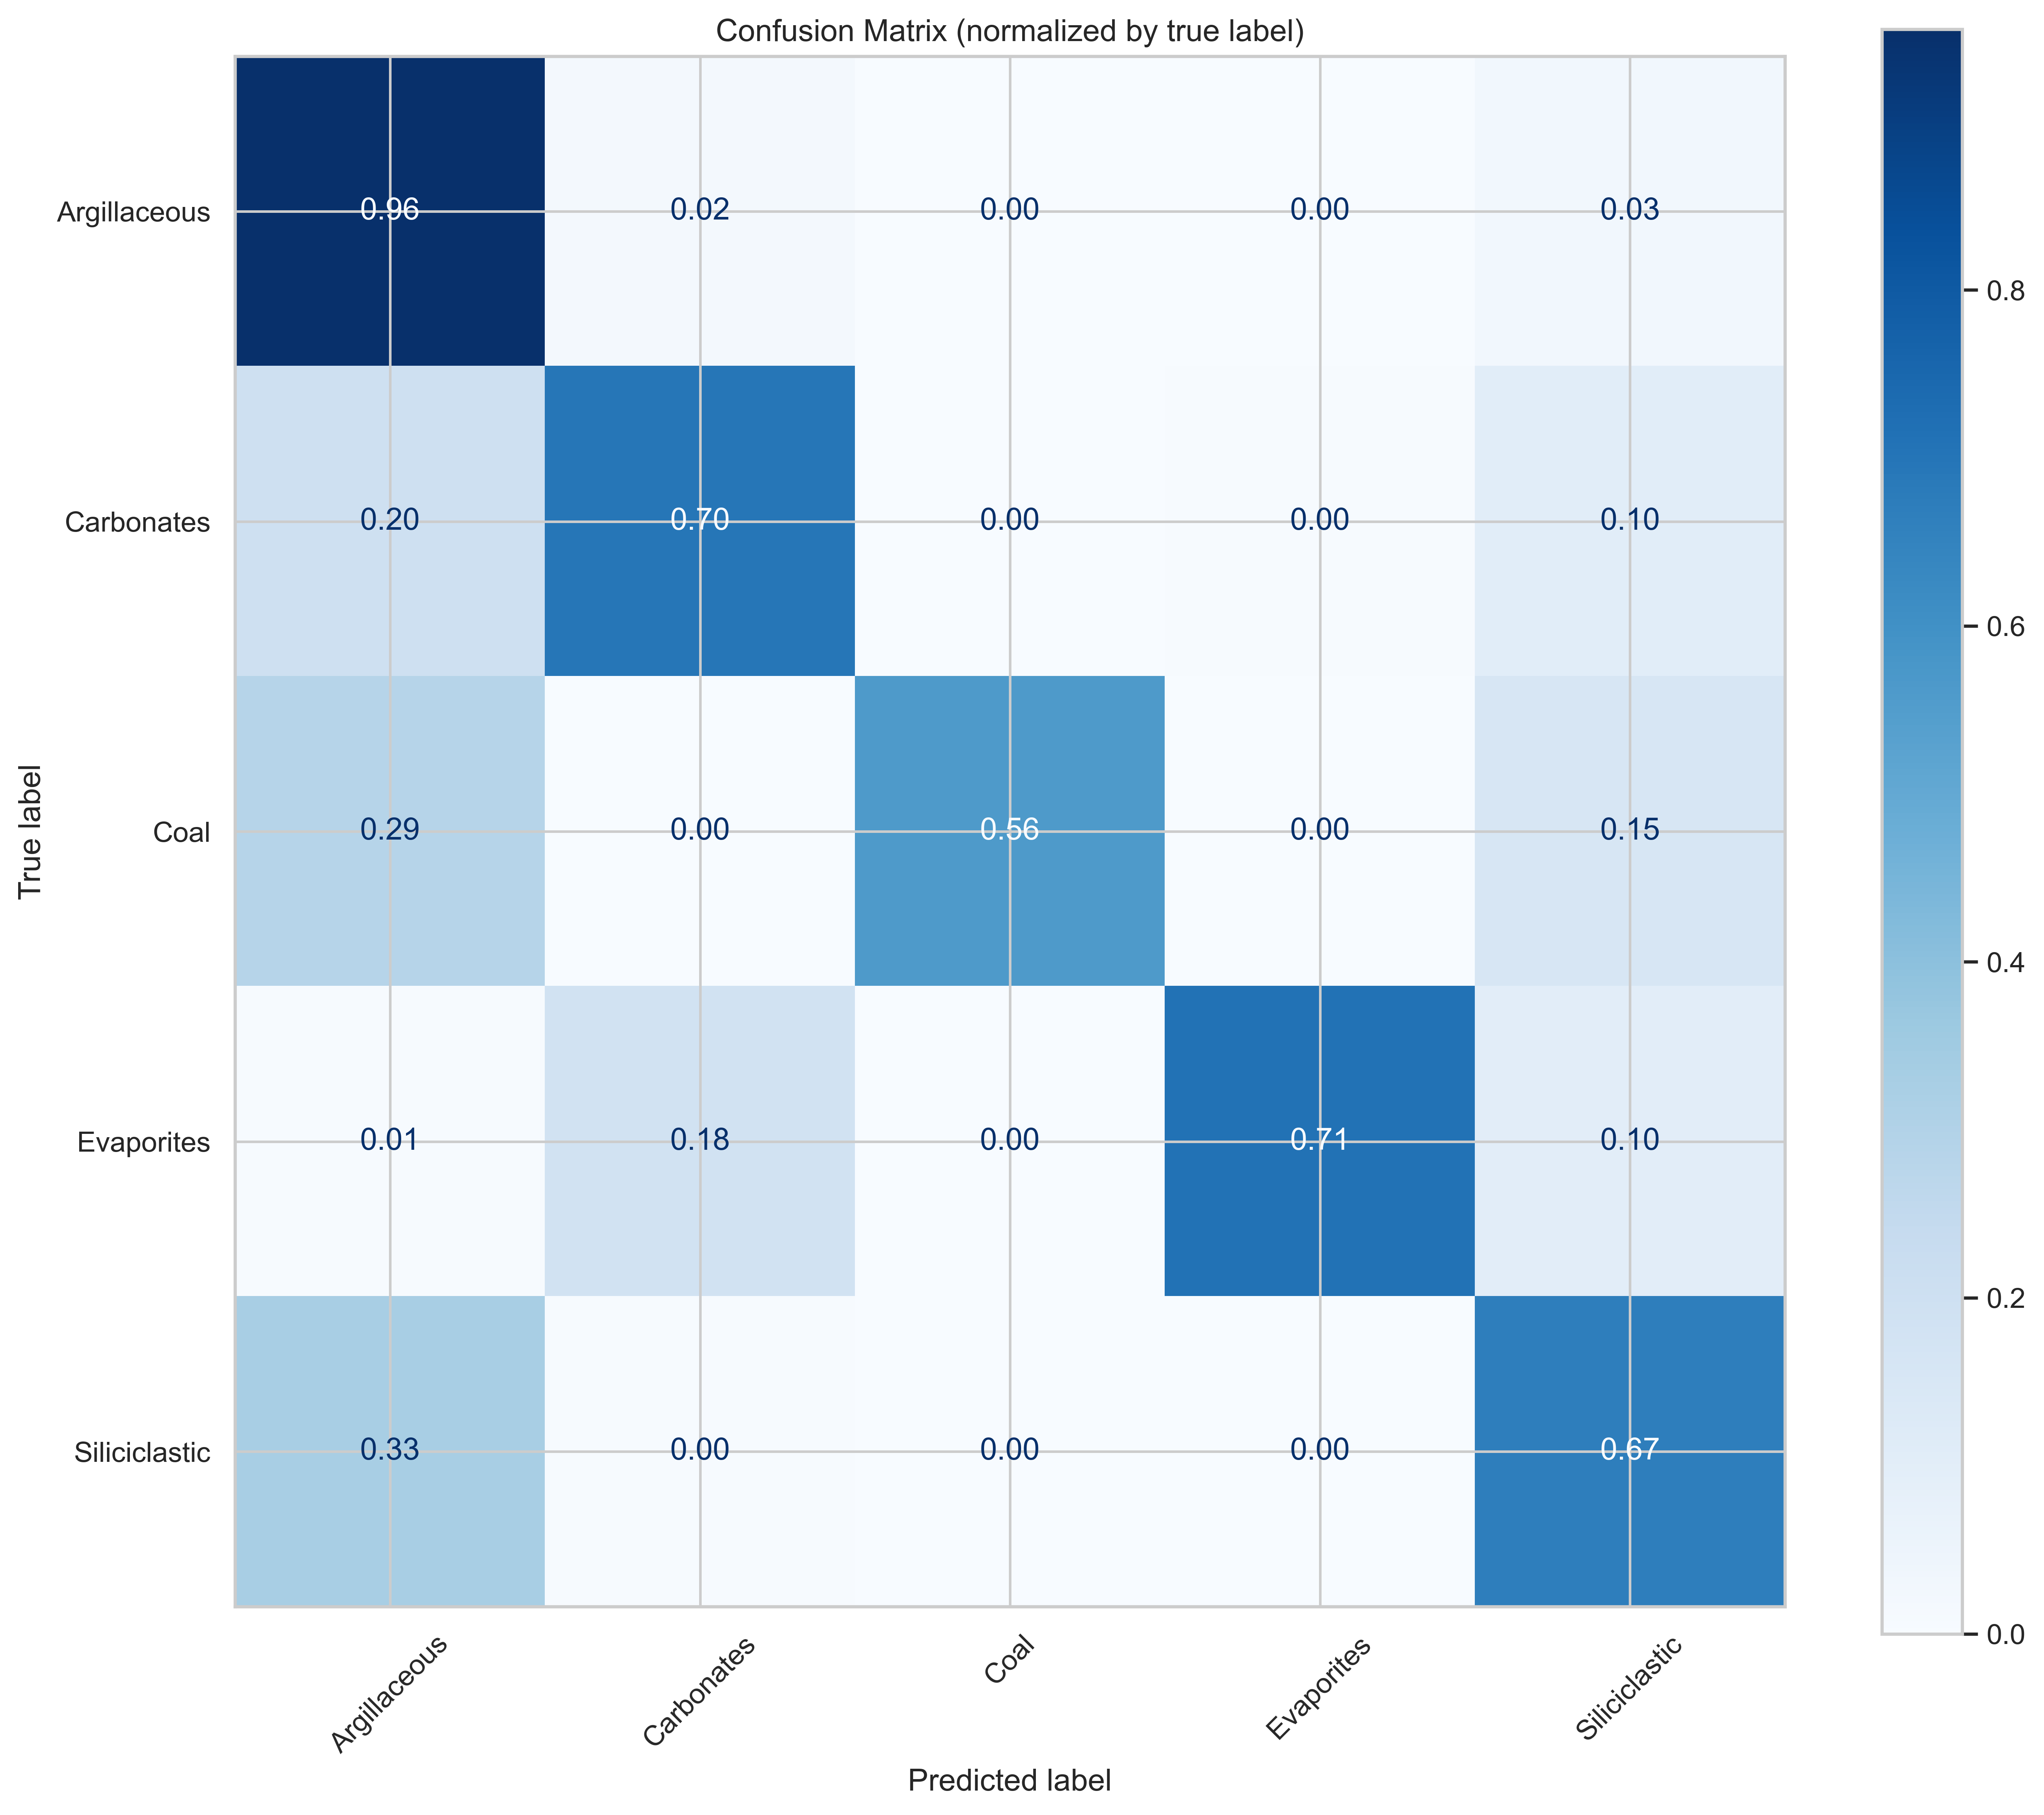

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/hyperimpute_rf_test/roc_auc_curves.png


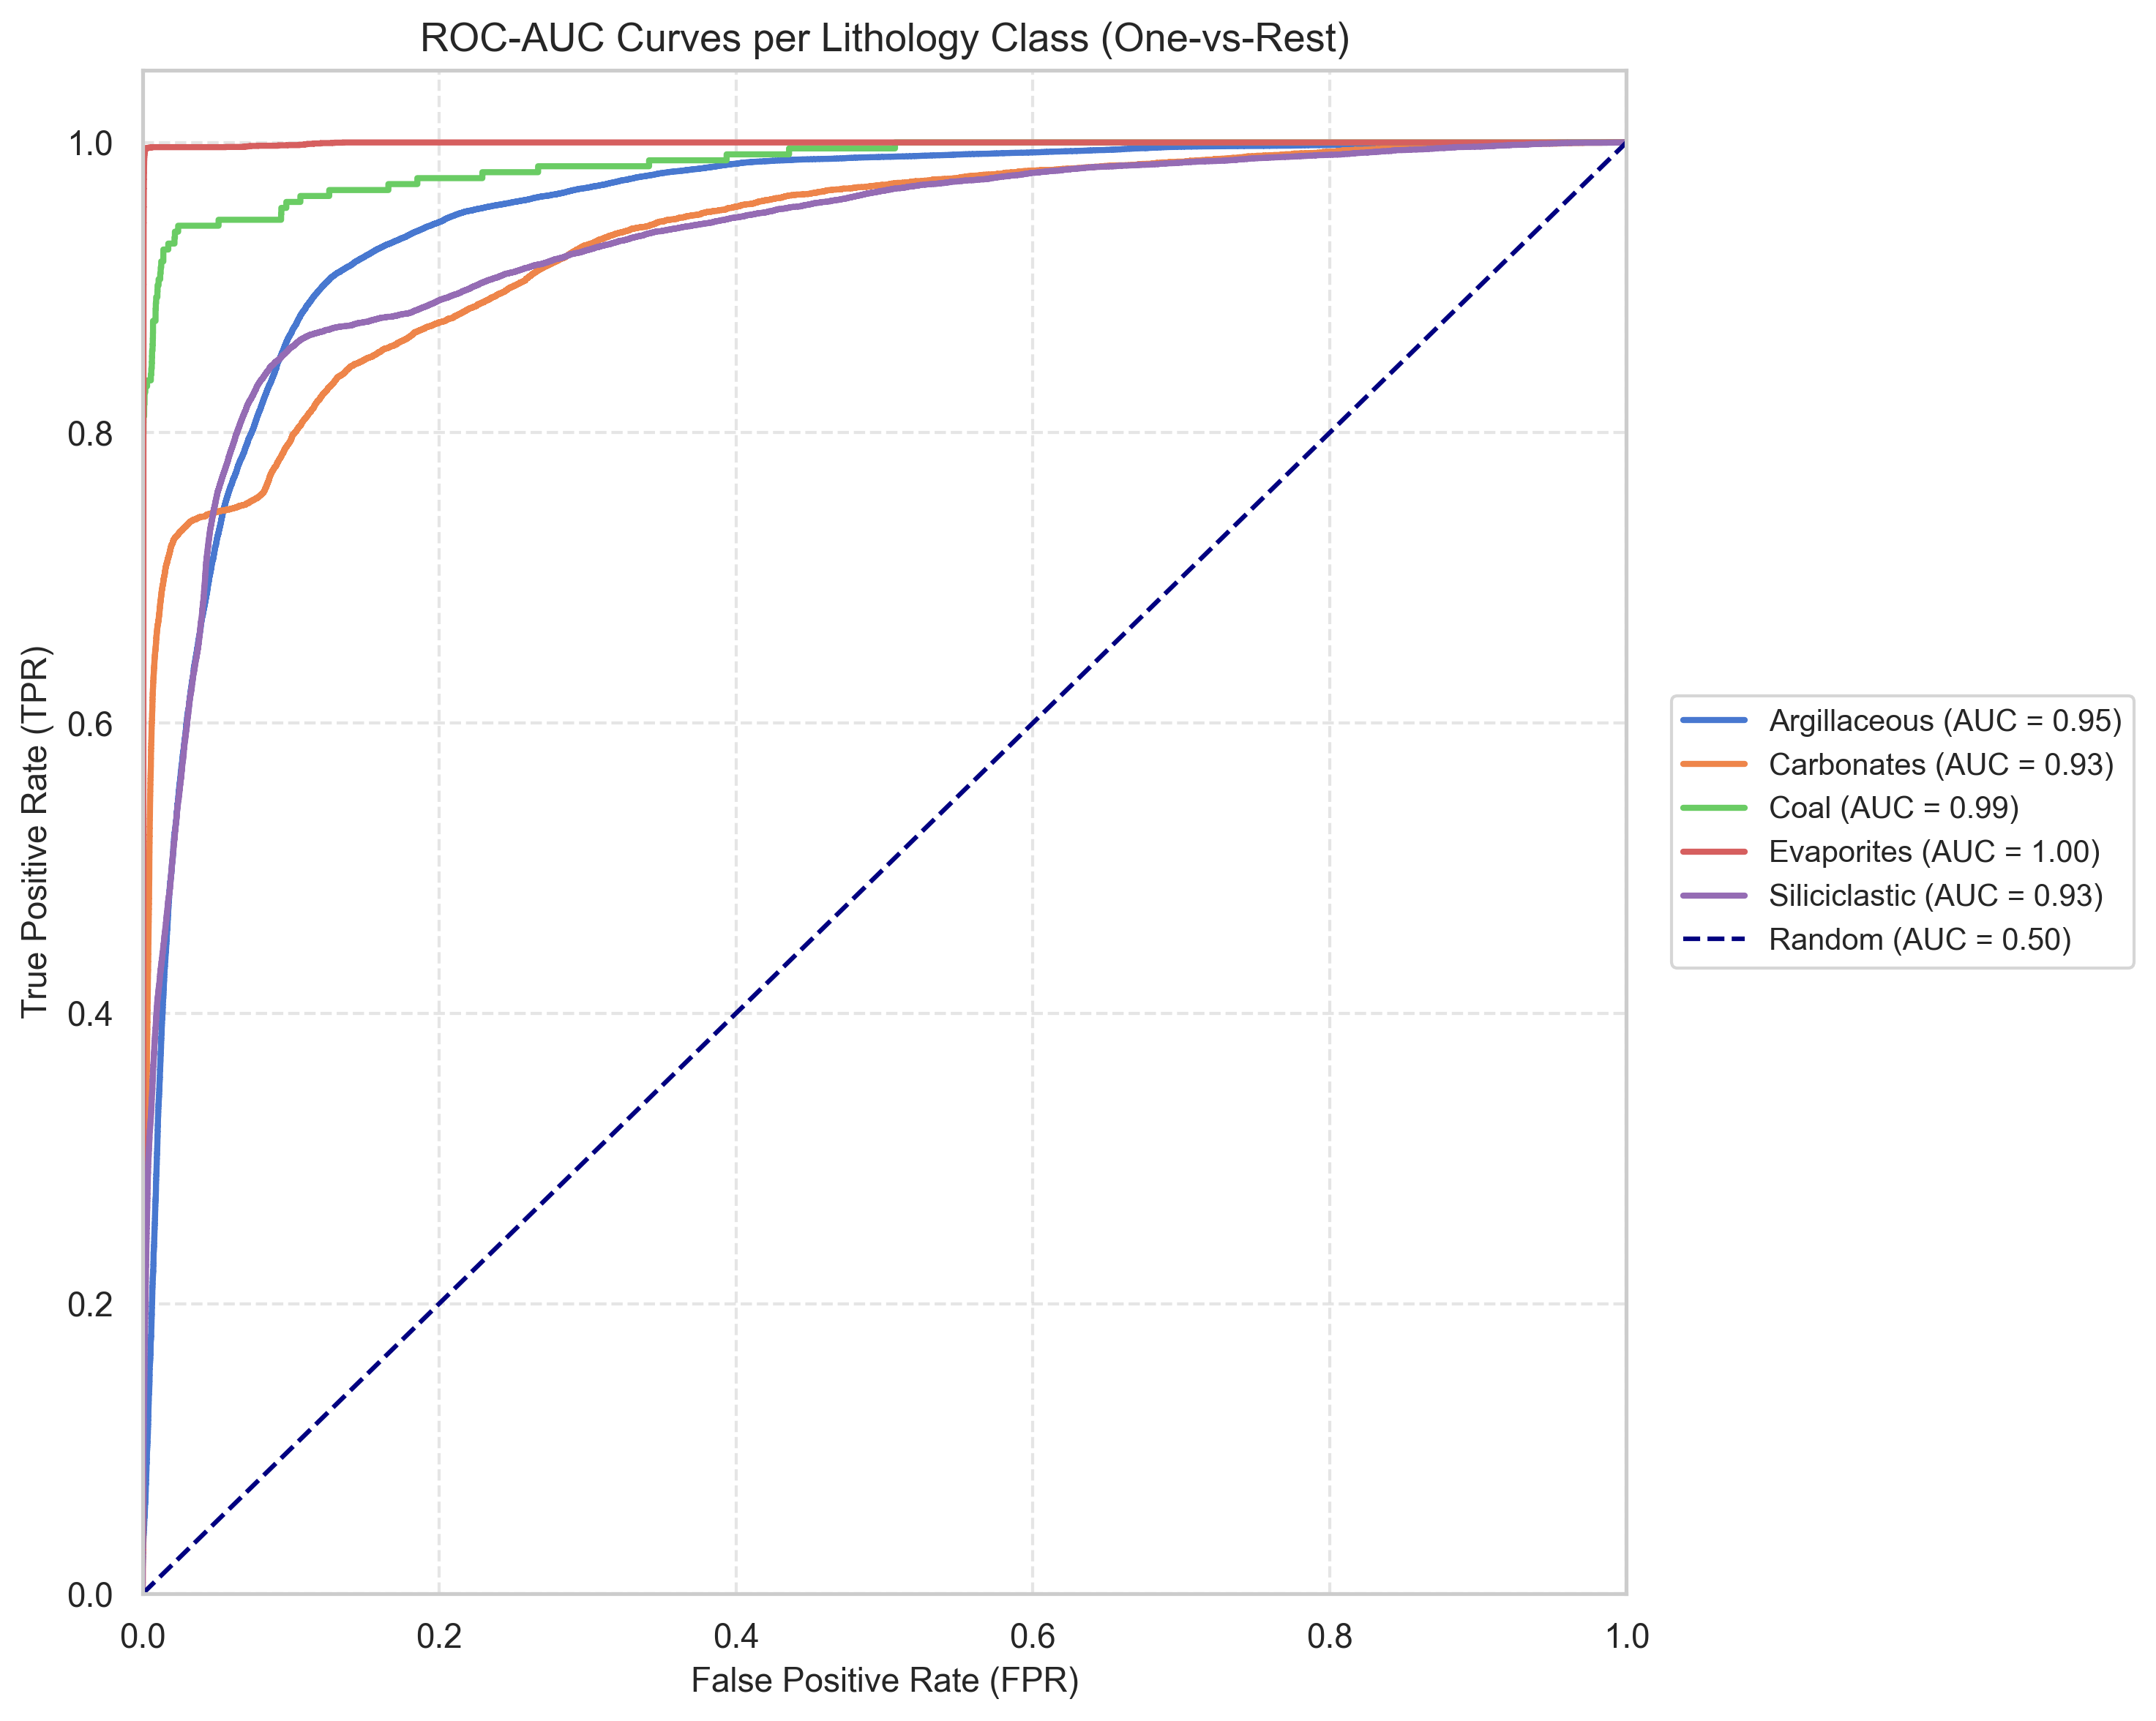

HyperImpute завершен!


In [1]:
import sys
import pandas as pd
from pathlib import Path


BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))
    
from src.models.hyperimpute_wrapper import HyperImputeWrapper
from src import GeophysicalFeatureExtractor, DataCleansing
from src.class_grouper import LithologyClassGrouper
from src.models.rf_cb_optuna import RandomForest
from src.metrics import LithologyEvaluator

df_train = pd.read_csv(BASE_DIR / "data/raw/train.csv", sep=';')
df_test = pd.read_csv(BASE_DIR / "data/raw/hidden_test.csv", sep=';')
df_test['WELL'] = df_test['WELL'].values
df_train['WELL'] = df_train['WELL'].values
feature_cols = ['RDEP', 'RMED', 'RSHA', 'RHOB', 'GR', 'NPHI', 'DTC']


imputer = HyperImputeWrapper(feature_cols=feature_cols, method="missforest")

df_train_imp = imputer.fit_transform(df_train)
df_test_imp = imputer.transform(df_test)

geo_extractor = GeophysicalFeatureExtractor()
df_train_geo = geo_extractor.transform(df_train_imp)
df_test_geo = geo_extractor.transform(df_test_imp)

cleansing = DataCleansing(
    cols_to_drop=[
        "X_LOC", "Y_LOC", "FORMATION", "SGR", "ROP", "PEF", 
        "RXO", "MUDWEIGHT", "DCAL", "RMIC", "ROPA",
        "FORCE_2020_LITHOFACIES_CONFIDENCE", "LITHO_NAME"
    ],
    cols_to_log=['RDEP', 'RMED', 'RSHA']
)
df_train_final = cleansing.transform(df_train_geo)
df_test_final = cleansing.transform(df_test_geo)


united_classes = {
    'Argillaceous': [65000, 80000, 99000],
    'Siliciclastic': [30000, 65030],
    'Carbonates': [70000, 70032, 74000],
    'Evaporites': [86000, 88000],
    'Coal': 90000,
    'Basement': 93000
}
grouper = LithologyClassGrouper(united_classes)

df_train_grouped = grouper.transform(df_train_final, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')
df_test_grouped = grouper.transform(df_test_final, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')

trainer = RandomForest(test_size=0.2, random_state=42)
trainer.tune_optuna(df_train_grouped, n_trials=5)

test_preds = trainer.predict(df_test_grouped)
test_probs = trainer.predict_proba(df_test_grouped)

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY'],
    y_pred=test_preds,
    val_probs=test_probs,
    classes=trainer.pipeline.classes_,
    output_dir=str(BASE_DIR / "reports/figures/hyperimpute_rf_test"),
)

print("HyperImpute завершен!")